In [1]:
!pip install kaggle -q
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer #convert email text to numbers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
print("All imported!")

All imported!


In [3]:
from google.colab import files
uploaded = files.upload()  #upload dataset

import pandas as pd
df = pd.read_csv("emails.csv", encoding="latin-1")
print(f"Dataset loaded! Shape: {df.shape}")
df.head()

Saving emails.csv to emails (1).csv
Dataset loaded! Shape: (5728, 2)


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [8]:
print(df.columns.tolist())
df = df[["text", "label"]] #Select features needed
print(df.isnull().sum())#null values detection
print(df["label"].value_counts())
df.dropna(inplace=True) #dropping if null
print(df.head())

['text', 'label']
text     0
label    0
dtype: int64
label
0    4360
1    1368
Name: count, dtype: int64
                                                text  label
0  Subject: naturally irresistible your corporate...      1
1  Subject: the stock trading gunslinger  fanny i...      1
2  Subject: unbelievable new homes made easy  im ...      1
3  Subject: 4 color printing special  request add...      1
4  Subject: do not have money , get software cds ...      1


In [9]:
X = df["text"]
y = df["label"]
vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)
X_vectorized = vectorizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42   #80% train 20% test
)
print(f"training set: {X_train.shape[0]}")
print(f"testing set:  {X_test.shape[0]}")

training set: 4582
testing set:  1146


In [10]:
lr_model = LogisticRegression(max_iter=1000) #logistic model
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)

dt_model = DecisionTreeClassifier(random_state=42) #decision model
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

print(f"Logistic Regression Accuracy : {lr_acc * 100:.2f}%")
print(f"Decision Tree Accuracy       : {dt_acc * 100:.2f}%")

#finding better model by comparing the accuracy of both
if lr_acc >= dt_acc:
    best_model = lr_model
    best_preds = lr_preds
    best_name = "Logistic Regression"
else:
    best_model = dt_model
    best_preds = dt_preds
    best_name = "Decision Tree"

print(f"\nBest Model: {best_name}")
print("\nClassification Report:")
print(classification_report(y_test, best_preds))

Logistic Regression Accuracy : 98.43%
Decision Tree Accuracy       : 95.72%

Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       856
           1       0.99      0.95      0.97       290

    accuracy                           0.98      1146
   macro avg       0.99      0.97      0.98      1146
weighted avg       0.98      0.98      0.98      1146



In [11]:
X_test_text = vectorizer.inverse_transform(X_test) #converting back to text
X_test_readable = [" ".join(words) for words in X_test_text]

print(f"{'EMAIL (truncated)':<60} {'ACTUAL':<12} {'PREDICTED'}")
print("-" * 90)

y_test_list = list(y_test)
for i in range(10):
    email_preview = X_test_readable[i][:57] + "..."
    actual = y_test_list[i]
    predicted = best_preds[i]
    match = "correct" if actual == predicted else "incorrect"
    print(f"{email_preview:<60} {actual:<12} {predicted}  {match}")

EMAIL (truncated)                                            ACTUAL       PREDICTED
------------------------------------------------------------------------------------------
subject information good special fax com ca great best da... 0            0  correct
subject just copy case financial course event refer doc v... 0            0  correct
subject promise original way com message great day 11 doe... 0            0  correct
subject trading credit time phone fax mail ca money accor... 0            0  correct
subject information gas forward represent 10 13 historica... 0            0  correct
subject com hello 20 2005 just safe id site internet free... 1            1  correct
subject effective look research know 08 12 need does revi... 0            0  correct
subject make like opportunity best changed know just numb... 0            0  correct
subject information good make use management provide resu... 0            0  correct
subject identity information business result group time c...

What are my features?
Here its subject, based on subject of mail it makes its predictions.

What is my label?
spam or not (spam means 1, not spam means 0)

what did the models learn?
It sees the kind of words present in the subject defined as spam and tries to find a pattern and learn likewise.

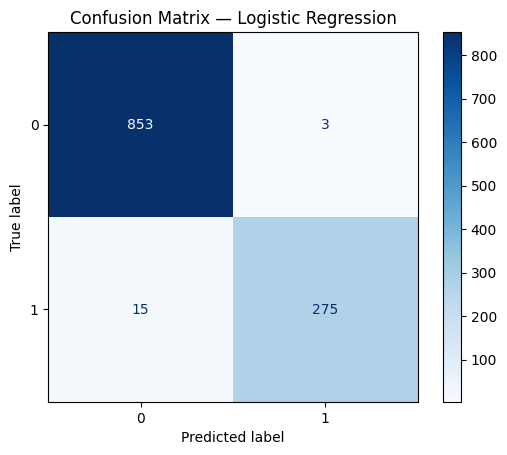

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

In [15]:
#using only 10 rows
X_tiny = X[:10]
y_tiny = y[:10]

X_tiny_vec = vectorizer.transform(X_tiny)
X_tiny_train, X_tiny_test, y_tiny_train, y_tiny_test = train_test_split(
    X_tiny_vec, y_tiny, test_size=0.2, random_state=42
)

tiny_model = LogisticRegression(max_iter=1000)

tiny_model.fit(X_tiny_train,y_tiny_train)
tiny_preds = tiny_model.predict(X_tiny_test)
tiny_acc = accuracy_score(y_tiny_test, tiny_preds)

print(f"Full dataset accuracy  : {lr_acc * 100:.2f}%")
print(f"Tiny dataset accuracy  : {tiny_acc * 100:.2f}%")
print(f"Drop in accuracy       : {(lr_acc - tiny_acc) * 100:.2f}%")
#error because all the first 10 rows were spam (problem with tiny datasets)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

High accuracy also bad. Suppose a dataset has 99 healthy ppl and 1 sick person (cancer) , will detect cancer person also healthy which is useless